In [2]:
import os
import sys
import argparse

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from data import *
from utils import *
from scipy import stats
from datetime import datetime
from matplotlib.patches import Rectangle

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig
from TCM import compute_tcm

from BA import oh_binary_accuracy

In [3]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=10_000, help='Total # of samples')                     # Maybe 10_000
parser.add_argument('--mb_size', type=int, default=128, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=24, help='Dim of latent vector')                   # Maybe 16, 32
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')   # Maybe 16, 48 or 64 if too blurry
parser.add_argument('--x_fdim', type=int, default=48, help='Input x_fdim. See utils.py')            # Maybe 96 or 128
parser.add_argument('--y_fdim', type=int, default=16, help='Input y_fdim. See utils.py')            # Maybe 10, 16, 20, 32
parser.add_argument('--c_accu', type=float, default=25, help='Input weight on recons_error')        # Maybe 10, 25, 50, 100

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')     # Maybe 3e-4, 1e-4, 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [4]:
_, xtest, ipVec_dim, nChannels = get_mnist_dataloader(args=opt)

In [5]:
def kPCA_1V(X, eps=1e-6):
    a = X @ X.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [6]:
def kPCA(X, Y, eps=1e-6):
    a = X @ X.T + Y @ Y.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [7]:
def extract_mnist_factors(img, threshold=0.1):
    """
    img: 2D numpy array, shape (H, W), assumed scaled to [0, 1]
    returns: dict of proxy generating factors
    """
    H, W = img.shape
    ys, xs = np.indices((H, W))

    mask = img > threshold
    if mask.sum() == 0:
        return {
            "x_center": 0.0,
            "y_center": 0.0,
            "width": 0.0,
            "height": 0.0,
            "area": 0.0,
            "angle": 0.0,
        }

    weights = img * mask
    total = weights.sum()

    x_center = (xs * weights).sum() / total
    y_center = (ys * weights).sum() / total

    x_active = xs[mask]
    y_active = ys[mask]
    width = x_active.max() - x_active.min() + 1
    height = y_active.max() - y_active.min() + 1
    area = mask.sum()

    # weighted covariance for principal orientation
    x_shift = xs - x_center
    y_shift = ys - y_center
    cov_xx = (weights * x_shift * x_shift).sum() / total
    cov_yy = (weights * y_shift * y_shift).sum() / total
    cov_xy = (weights * x_shift * y_shift).sum() / total

    angle = 0.5 * np.arctan2(2 * cov_xy, cov_xx - cov_yy)
    return [x_center, y_center, width, height, area, angle]
    # return {
    #     "x_center": float(x_center),
    #     "y_center": float(y_center),
    #     "width": float(width),
    #     "height": float(height),
    #     "area": float(area),
    #     "angle": float(angle),
    # }

In [8]:
def discretize_factors(F, n_bins=10):
    F = np.asarray(F, dtype=float)
    F_disc = np.zeros_like(F, dtype=int)

    for j in range(F.shape[1]):
        x = F[:, j]

        # If constant, keep all zero
        if np.allclose(x, x[0]):
            F_disc[:, j] = 0
            continue

        edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
        edges = np.unique(edges)

        if len(edges) <= 2:
            F_disc[:, j] = 0
        else:
            F_disc[:, j] = np.digitize(x, edges[1:-1], right=False)

    return F_disc

In [9]:
model = torch.load('out/Final.tar', weights_only=False)
model_sv = torch.load('out/Final-1V.tar', weights_only=False)

net1 = model['net1']
net2 = model['net2']
net3 = model['net3']
net4 = model['net4']

net1_sv = model_sv['net1']
net3_sv = model_sv['net3']

In [10]:
all_data_im = []
all_data_la = []

all_im_en_sv = []
all_im_en = []
all_la_en = []

DCI_D_1Vs, DCI_D_2Vs = [], []
DCI_C_1Vs, DCI_C_2Vs = [], []
DCI_I_1Vs, DCI_I_2Vs = [], []
IRS_1Vs, IRS_2Vs = [], []
MIG_1Vs, MIG_2Vs = [], []
TCM_1Vs, TCM_2Vs = [], []

In [11]:
with torch.no_grad():
    for datax, datay in xtest:
        datax = datax.to(opt.device)
        datay = datay.to(opt.device)

        all_data_im.append(datax)
        all_data_la.append(datay)

        x_en_sv = net1_sv(datax)
        x_en = net1(datax)
        y_en = net2(datay)

        all_im_en_sv.append(x_en_sv)
        all_im_en.append(x_en)
        all_la_en.append(y_en)

In [12]:
all_im_en_sv = torch.cat(all_im_en_sv, dim=0)[:1000]

all_la_en = torch.cat(all_la_en, dim=0)[:1000]
all_im_en = torch.cat(all_im_en, dim=0)[:1000]

all_data_im = torch.cat(all_data_im, dim=0)[:1000]
all_data_la = torch.cat(all_data_la, dim=0)[:1000]

# Only for plotting ---
all_im_de_sv = []
all_im_de = []
all_la_de = []
# ---

sv_losses = []
mv_im_losses = []
mv_la_losses = []
mv_total_losses = []

recon_loss1 = torch.nn.MSELoss()
recon_loss2 = torch.nn.CrossEntropyLoss()

In [13]:
def drop_constant_columns(Z, factor_types, min_per_class=10):
    valid_cols = []

    for j in range(Z.shape[1]):
        vals, counts = torch.unique(Z[:, j], return_counts=True)
        count_dict = dict(zip(vals.tolist(), counts.tolist()))

        n0 = count_dict.get(0, 0)
        n1 = count_dict.get(1, 0)

        if n0 < min_per_class or n1 < min_per_class:
            print(f" > Column {j} dropped: 0={n0}, 1={n1}")
        else:
            valid_cols.append(j)

    return Z[:, valid_cols], [factor_types[j] for j in valid_cols]

In [14]:
with torch.no_grad():
    for i in range(10):
        start, stop = i*100, (i+1)*100
        h_test_sv, _ = kPCA_1V(all_im_en_sv[start:stop])
        h_test, _ = kPCA(all_im_en[start:stop], all_la_en[start:stop])

        U_test_sv = all_im_en_sv[start:stop].t() @ h_test_sv
        U_test = all_im_en[start:stop].t() @ h_test
        V_test = all_la_en[start:stop].t() @ h_test

        x_im_tilde_test_sv = net3_sv(h_test_sv @ U_test_sv.T)
        x_im_tilde_test = net3(h_test @ U_test.T)
        y_la_tilde_test = net4(h_test @ V_test.T)

        loss_im_sv = recon_loss1(x_im_tilde_test_sv.view(-1, ipVec_dim), all_data_im[start:stop].view(-1, ipVec_dim))
        loss_im_all = recon_loss1(x_im_tilde_test.view(-1, ipVec_dim), all_data_im[start:stop].view(-1, ipVec_dim))
        loss_la_all = recon_loss2(y_la_tilde_test.view(-1, 10), all_data_la[start:stop].argmax(dim=1).long())

        sv_losses.append(loss_im_sv.item())
        mv_im_losses.append(loss_im_all.item())
        mv_la_losses.append(loss_la_all.item())
        mv_total_losses.append((loss_im_all.item() + loss_la_all.item())/2)

        if i == 0:
            all_im_de_sv.append(x_im_tilde_test_sv.cpu()[:6])
            all_im_de.append(x_im_tilde_test.cpu()[:6])
            all_la_de.append(y_la_tilde_test.cpu()[:6])

        calculated_factors = [extract_mnist_factors(img.cpu().numpy().reshape(28, 28)) for img in all_data_im[start:stop]]
        gen_factors_disc = discretize_factors(calculated_factors, n_bins=10)
        # concat gen_factors and label into Z as a tensor
        Z = torch.cat([torch.tensor(gen_factors_disc, device=h_test.device), all_data_la[start:stop].argmax(dim=1, keepdim=True)], dim=1)
        factor_types = ['discrete'] * Z.shape[1]

        Z, factor_types = drop_constant_columns(Z, factor_types, min_per_class=3)

        DCI_1V = compute_dci(h_test_sv, Z, factor_types)
        DCI_2V = compute_dci(h_test, Z, factor_types)

        IRS_1V = compute_irs(h_test_sv, Z)
        IRS_2V = compute_irs(h_test, Z)

        MIG_1V = compute_mig(h_test_sv, Z)
        MIG_2V = compute_mig(h_test, Z)

        TCM_1V = compute_tcm(Z, h_test_sv)
        TCM_2V = compute_tcm(Z, h_test)

        DCI_D_1Vs.append(DCI_1V['D'])
        DCI_D_2Vs.append(DCI_2V['D'])
        DCI_C_1Vs.append(DCI_1V['C'])
        DCI_C_2Vs.append(DCI_2V['C'])
        DCI_I_1Vs.append(DCI_1V['I'])
        DCI_I_2Vs.append(DCI_2V['I'])
        IRS_1Vs.append(IRS_1V['IRS'])
        IRS_2Vs.append(IRS_2V['IRS'])
        MIG_1Vs.append(MIG_1V['MIG'])
        MIG_2Vs.append(MIG_2V['MIG'])
        TCM_2Vs.append(TCM_2V)
        TCM_1Vs.append(TCM_1V)

        print(f'Batch {i+1}/10 - Reconstruction loss (images) 1V: {loss_im_sv.item():.4f}, All: {loss_im_all.item():.4f}, Labels: {loss_la_all.item():.4f}, Total: {(loss_im_all.item() + loss_la_all.item())/2:.4f}')

 > Column 3 dropped: 0=100, 1=0
Batch 1/10 - Reconstruction loss (images) 1V: 0.0073, All: 0.0081, Labels: 0.0000, Total: 0.0041
 > Column 3 dropped: 0=100, 1=0
Batch 2/10 - Reconstruction loss (images) 1V: 0.0073, All: 0.0080, Labels: 0.0000, Total: 0.0040
 > Column 3 dropped: 0=100, 1=0
Batch 3/10 - Reconstruction loss (images) 1V: 0.0079, All: 0.0088, Labels: 0.0000, Total: 0.0044
 > Column 3 dropped: 0=100, 1=0
Batch 4/10 - Reconstruction loss (images) 1V: 0.0083, All: 0.0095, Labels: 0.0000, Total: 0.0047
 > Column 3 dropped: 0=100, 1=0
Batch 5/10 - Reconstruction loss (images) 1V: 0.0076, All: 0.0083, Labels: 0.0000, Total: 0.0042
 > Column 3 dropped: 0=100, 1=0
Batch 6/10 - Reconstruction loss (images) 1V: 0.0078, All: 0.0091, Labels: 0.0000, Total: 0.0046
 > Column 3 dropped: 0=100, 1=0
Batch 7/10 - Reconstruction loss (images) 1V: 0.0077, All: 0.0087, Labels: 0.0000, Total: 0.0043
 > Column 3 dropped: 0=100, 1=0
Batch 8/10 - Reconstruction loss (images) 1V: 0.0082, All: 0.0099

## Statistical Tests

In [15]:
t_stat, p_value = stats.ttest_rel(sv_losses, mv_im_losses)

print(f'T-statistic: {t_stat:.4f}, P-value: {p_value}')

T-statistic: -9.9942, P-value: 3.5954650034941958e-06


In [16]:
t_stat, p_value = stats.ttest_rel(sv_losses, mv_total_losses)

print(f'T-statistic: {t_stat:.4f}, P-value: {p_value}')

T-statistic: 65.8385, P-value: 2.172041437050674e-13


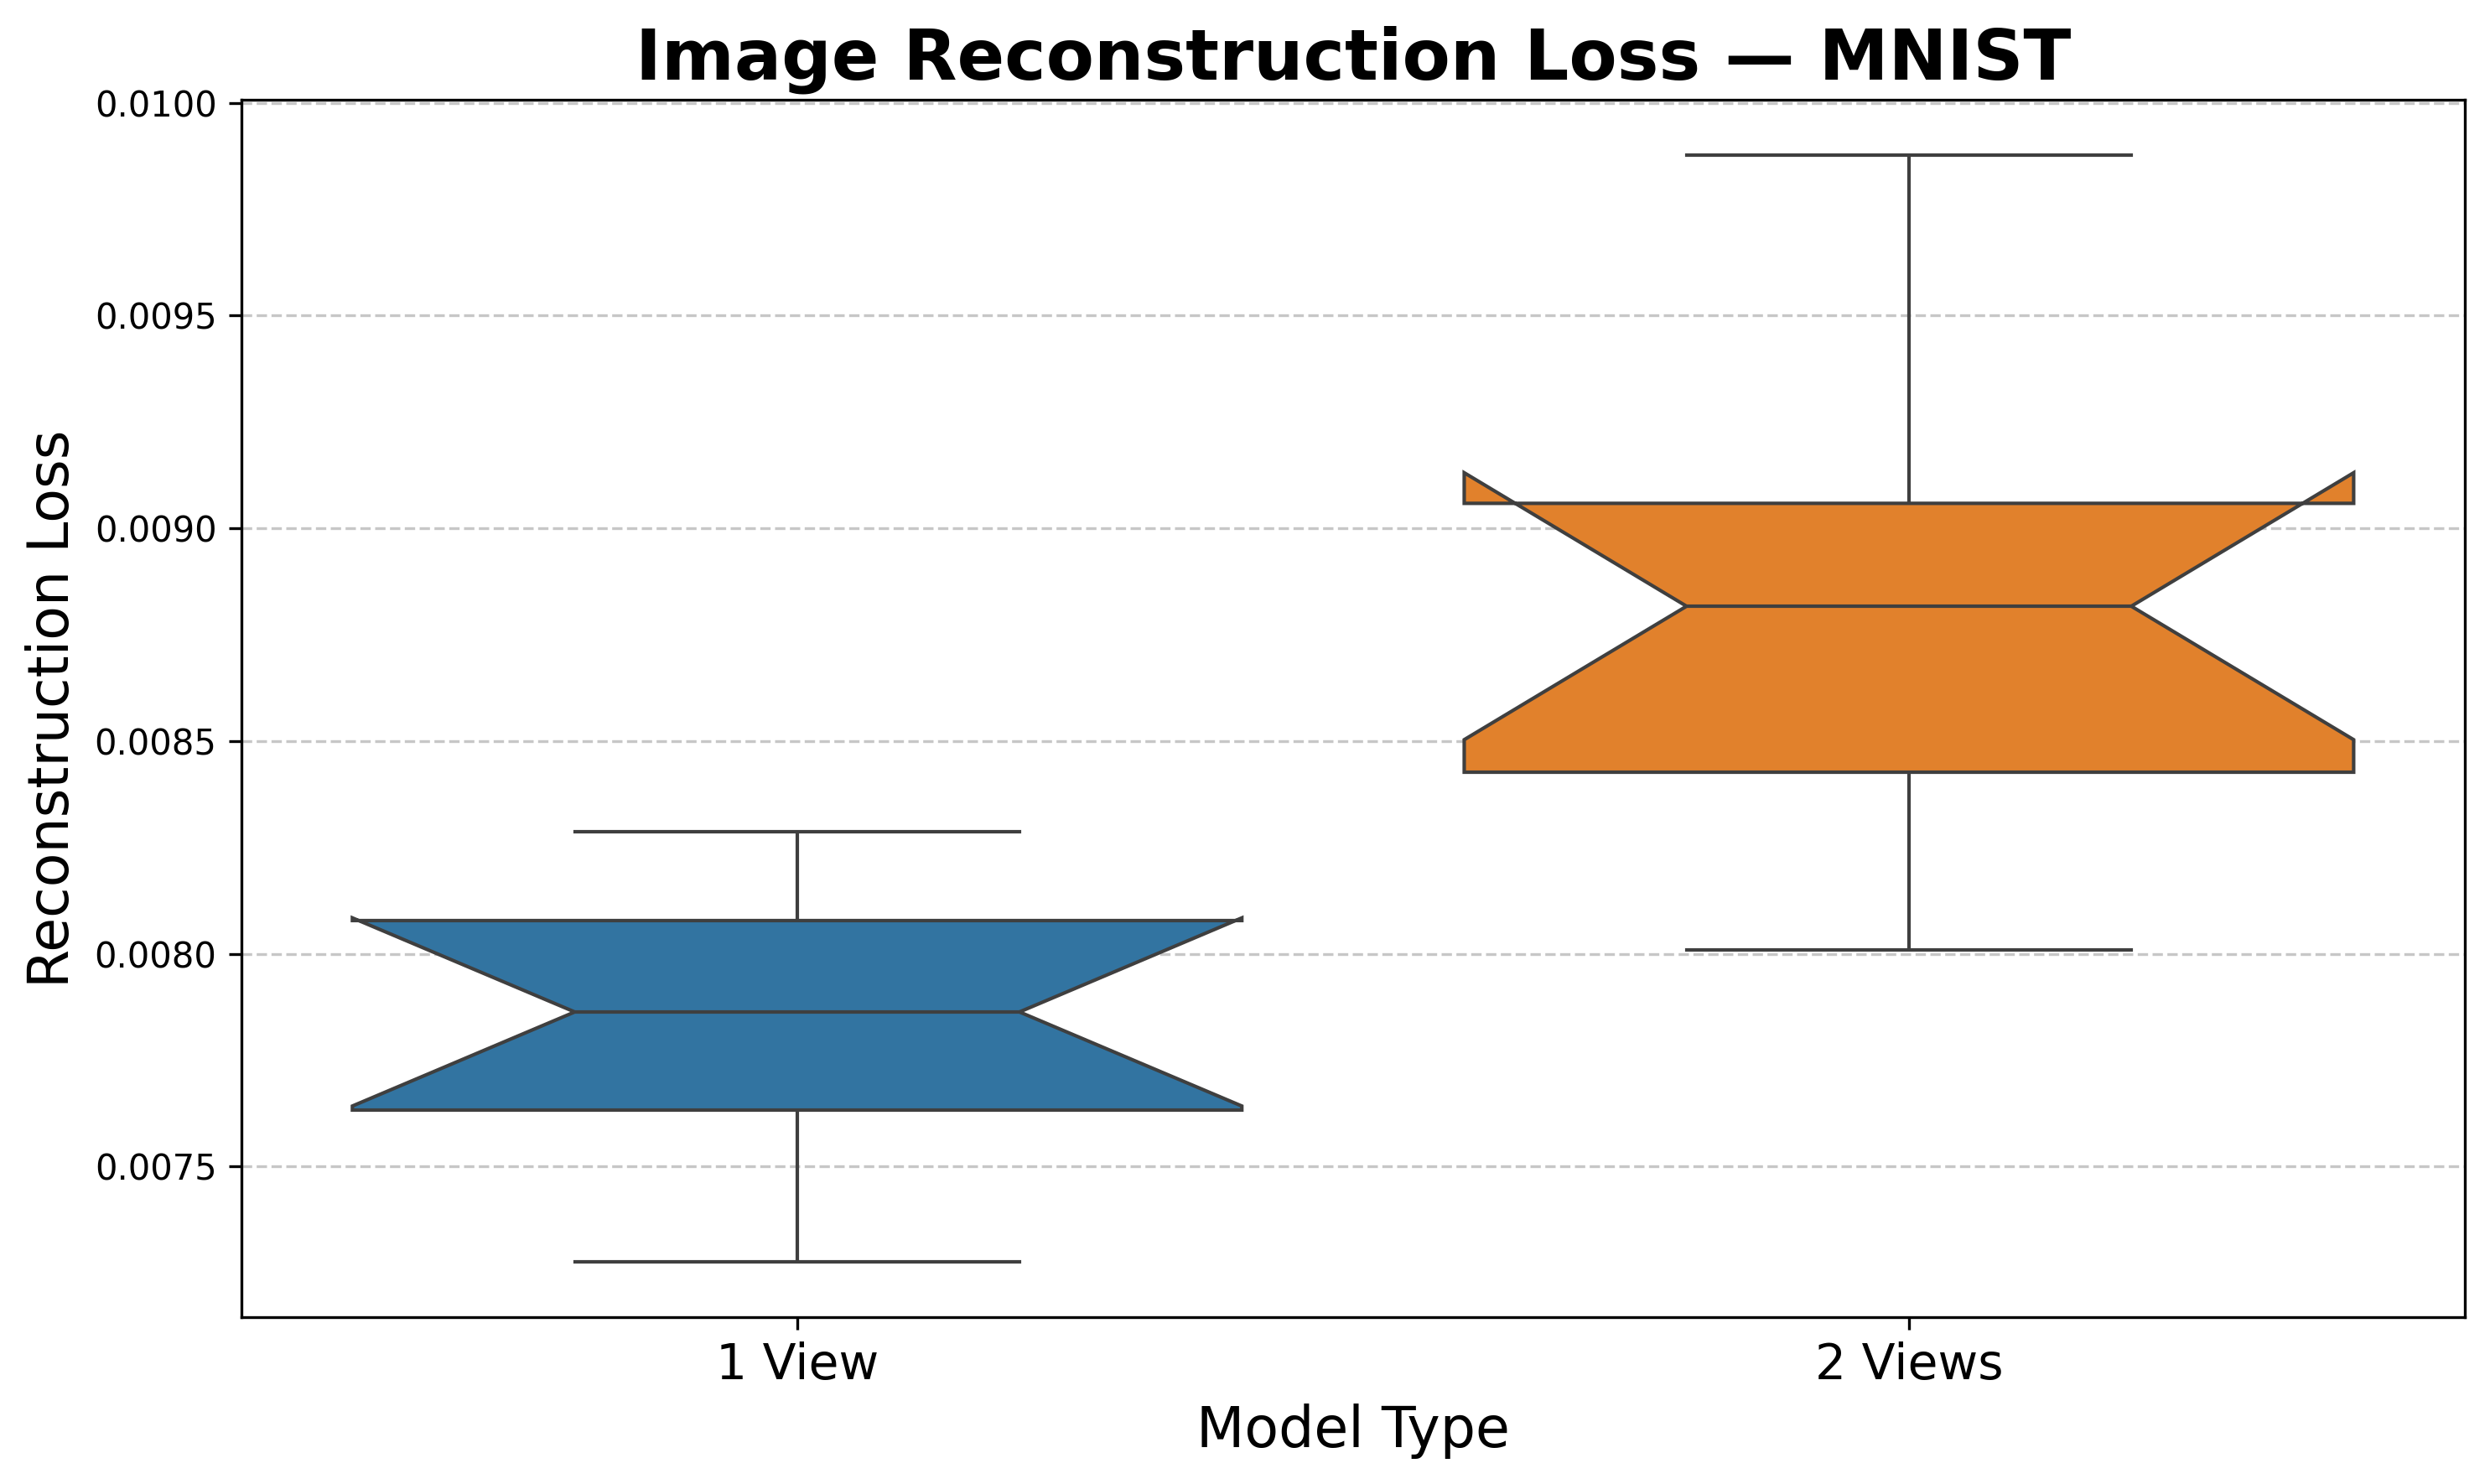

In [17]:
data = [sv_losses, mv_im_losses]
labels = ['1 View', '2 Views']

plt.figure(figsize=(10, 6), dpi=300)
plt.title('Image Reconstruction Loss — MNIST', fontsize=20, fontweight='bold')
sns.boxplot(data=data, notch=True)

plt.xticks(ticks=range(len(labels)), labels=labels, fontsize=14)
plt.xlabel('Model Type', fontsize=16)
plt.ylabel('Reconstruction Loss', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('img/boxplot_reconstruction_loss_comparison.png', dpi=300)

plt.show()

In [18]:
len(all_data_im)

1000

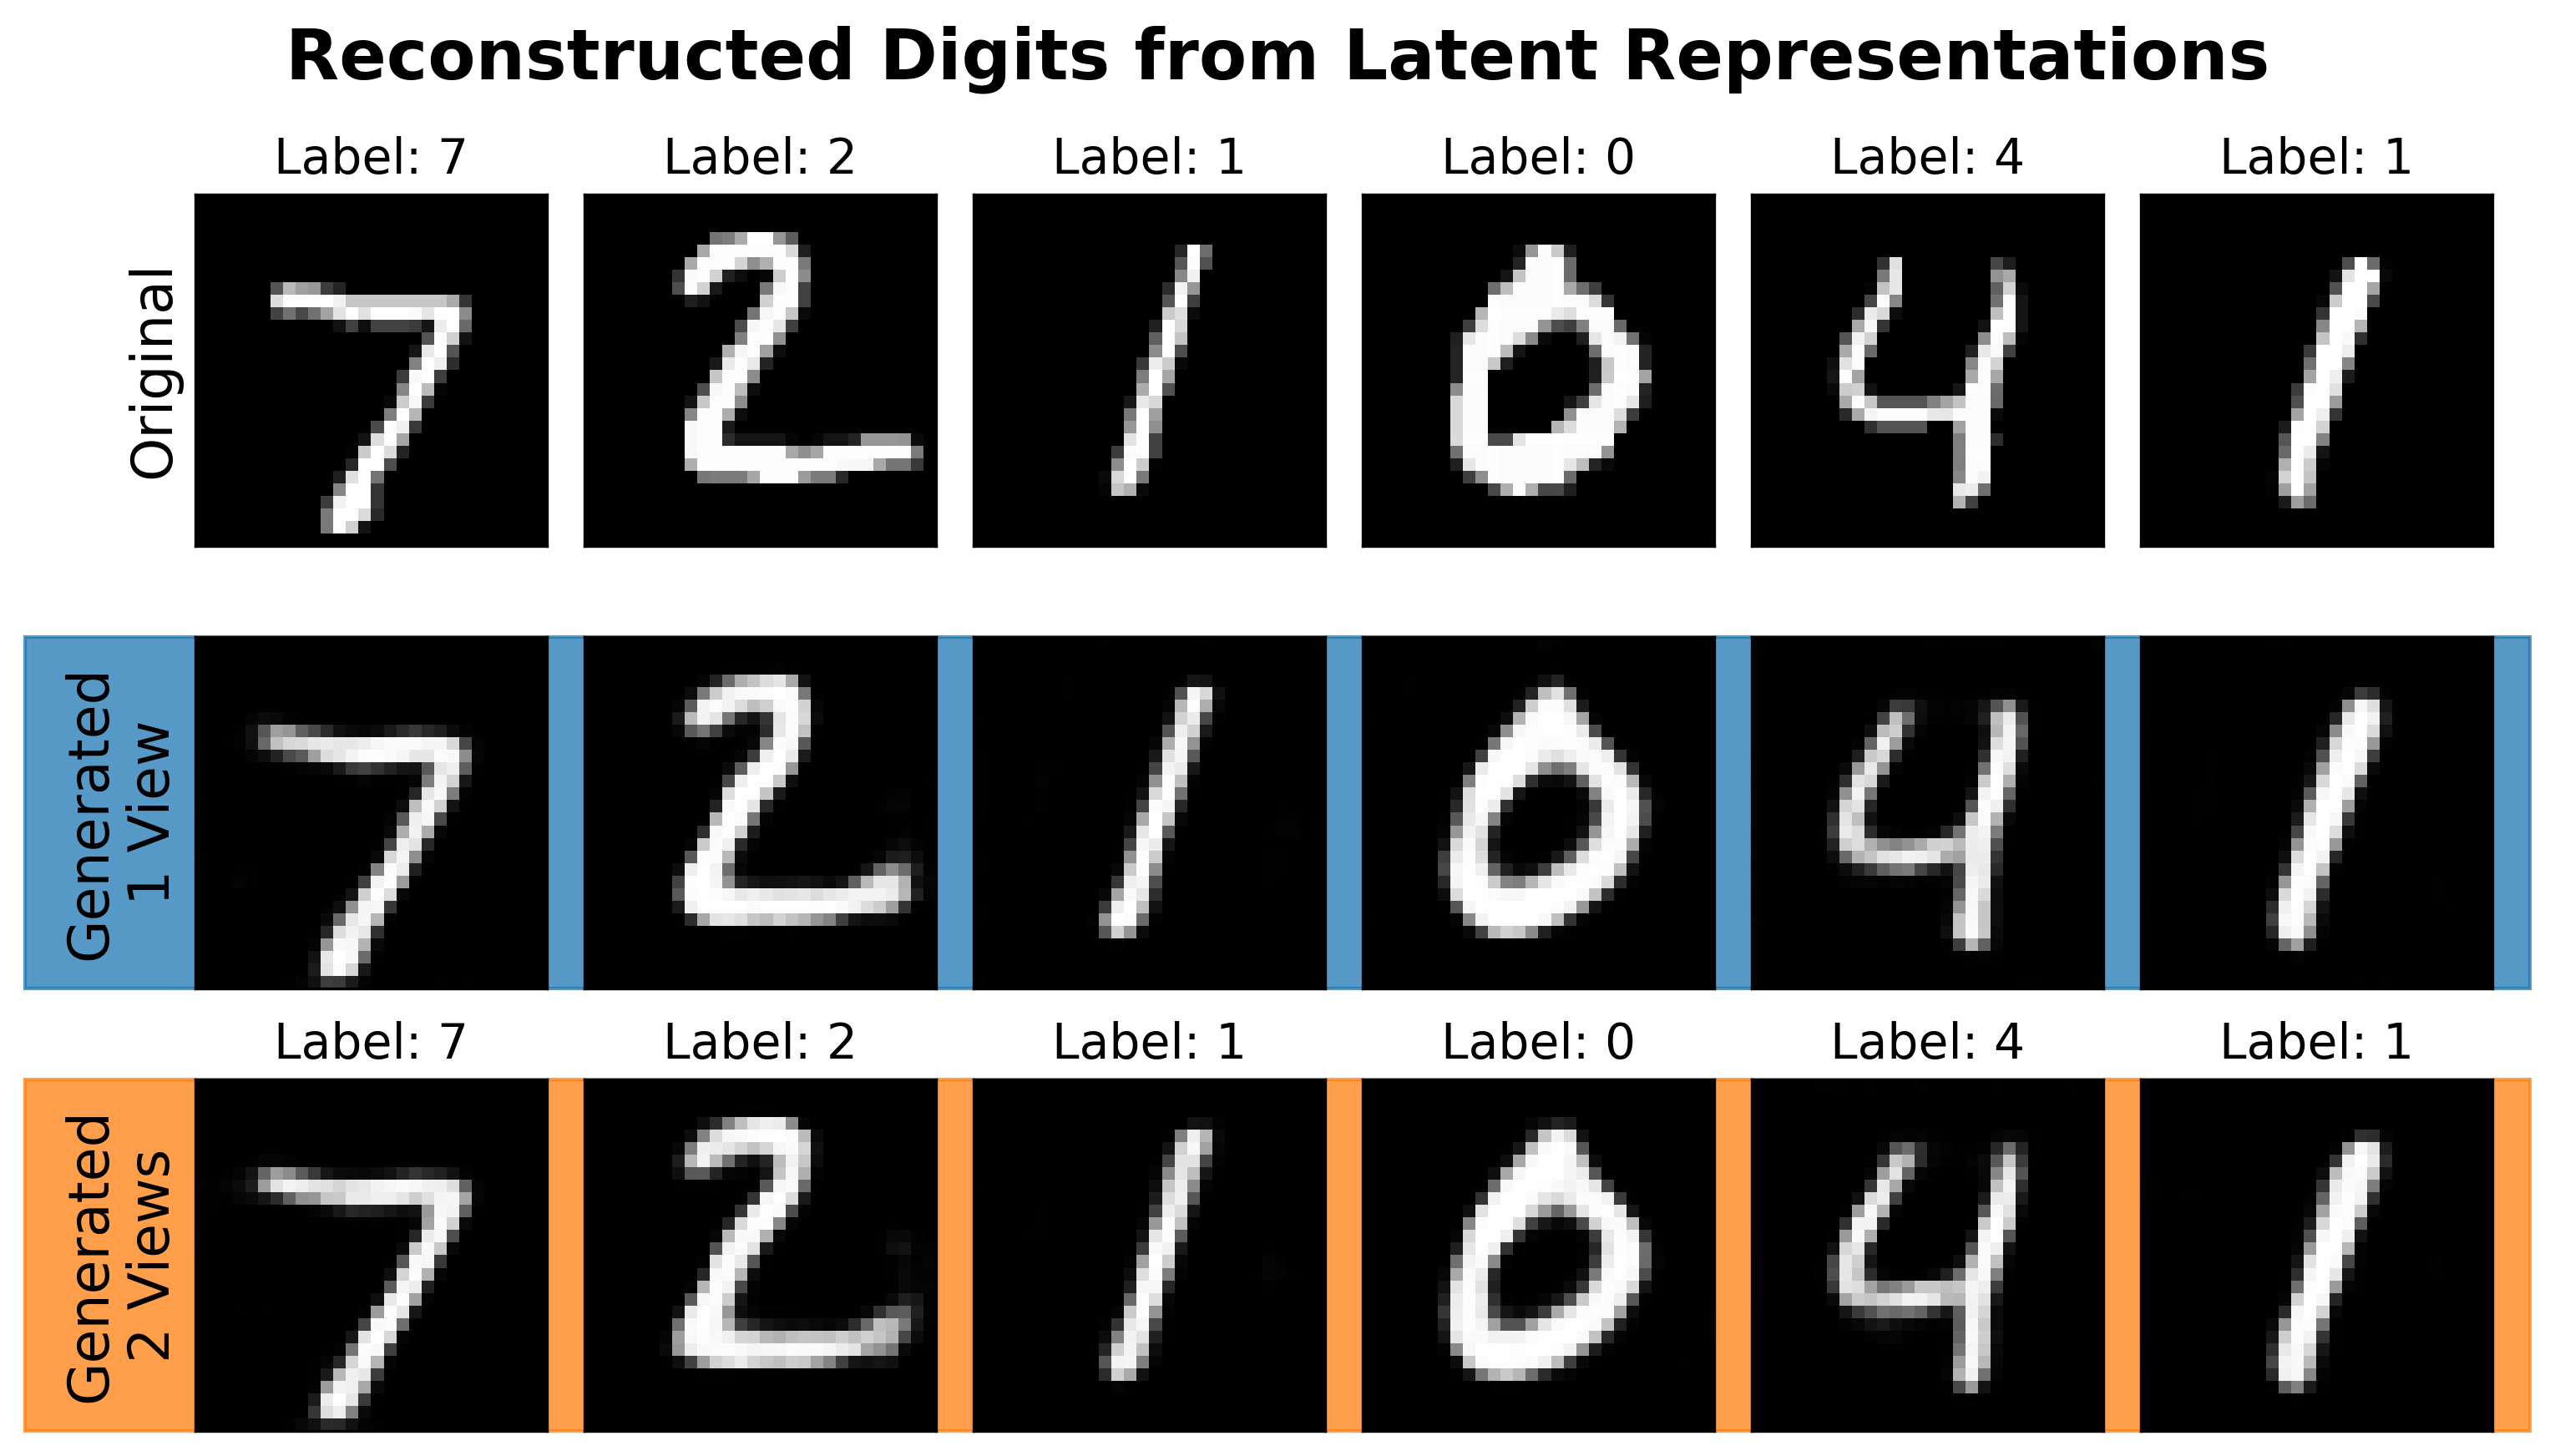

In [19]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(3, 6, figsize=(10, 6), dpi=300)

for idx in range(6):
    axes[0, 0].set_ylabel('\nOriginal', fontsize=16, rotation=90)
    axes[1, 0].set_ylabel('Generated\n1 View', fontsize=16, rotation=90)
    axes[2, 0].set_ylabel('Generated\n2 Views', fontsize=16, rotation=90)

    axes[0, idx].imshow(all_data_im[idx].reshape(28, 28), cmap='gray')
    axes[0, idx].set_title('Label: {}'.format(all_data_la[idx].argmax()), fontsize=14)

    axes[1, idx].imshow(all_im_de_sv[0][idx].reshape(28, 28), cmap='gray')

    axes[2, idx].imshow(all_im_de[0][idx].reshape(28, 28), cmap='gray')
    axes[2, idx].set_title('Label: {}'.format(all_la_de[0][idx].argmax()), fontsize=14)

    axes[0, idx].set_xticks([])
    axes[0, idx].set_yticks([])
    axes[1, idx].set_xticks([])
    axes[1, idx].set_yticks([])
    axes[2, idx].set_xticks([])
    axes[2, idx].set_yticks([])

plt.suptitle('Reconstructed Digits from Latent Representations', fontsize=20, fontweight='bold')
plt.tight_layout()

row_colors = [None, 'tab:blue', 'tab:orange']

for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = axes[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )

plt.savefig('img/reconstruction_loss_comparison.png', dpi=300)
plt.show()

## Disentanglement

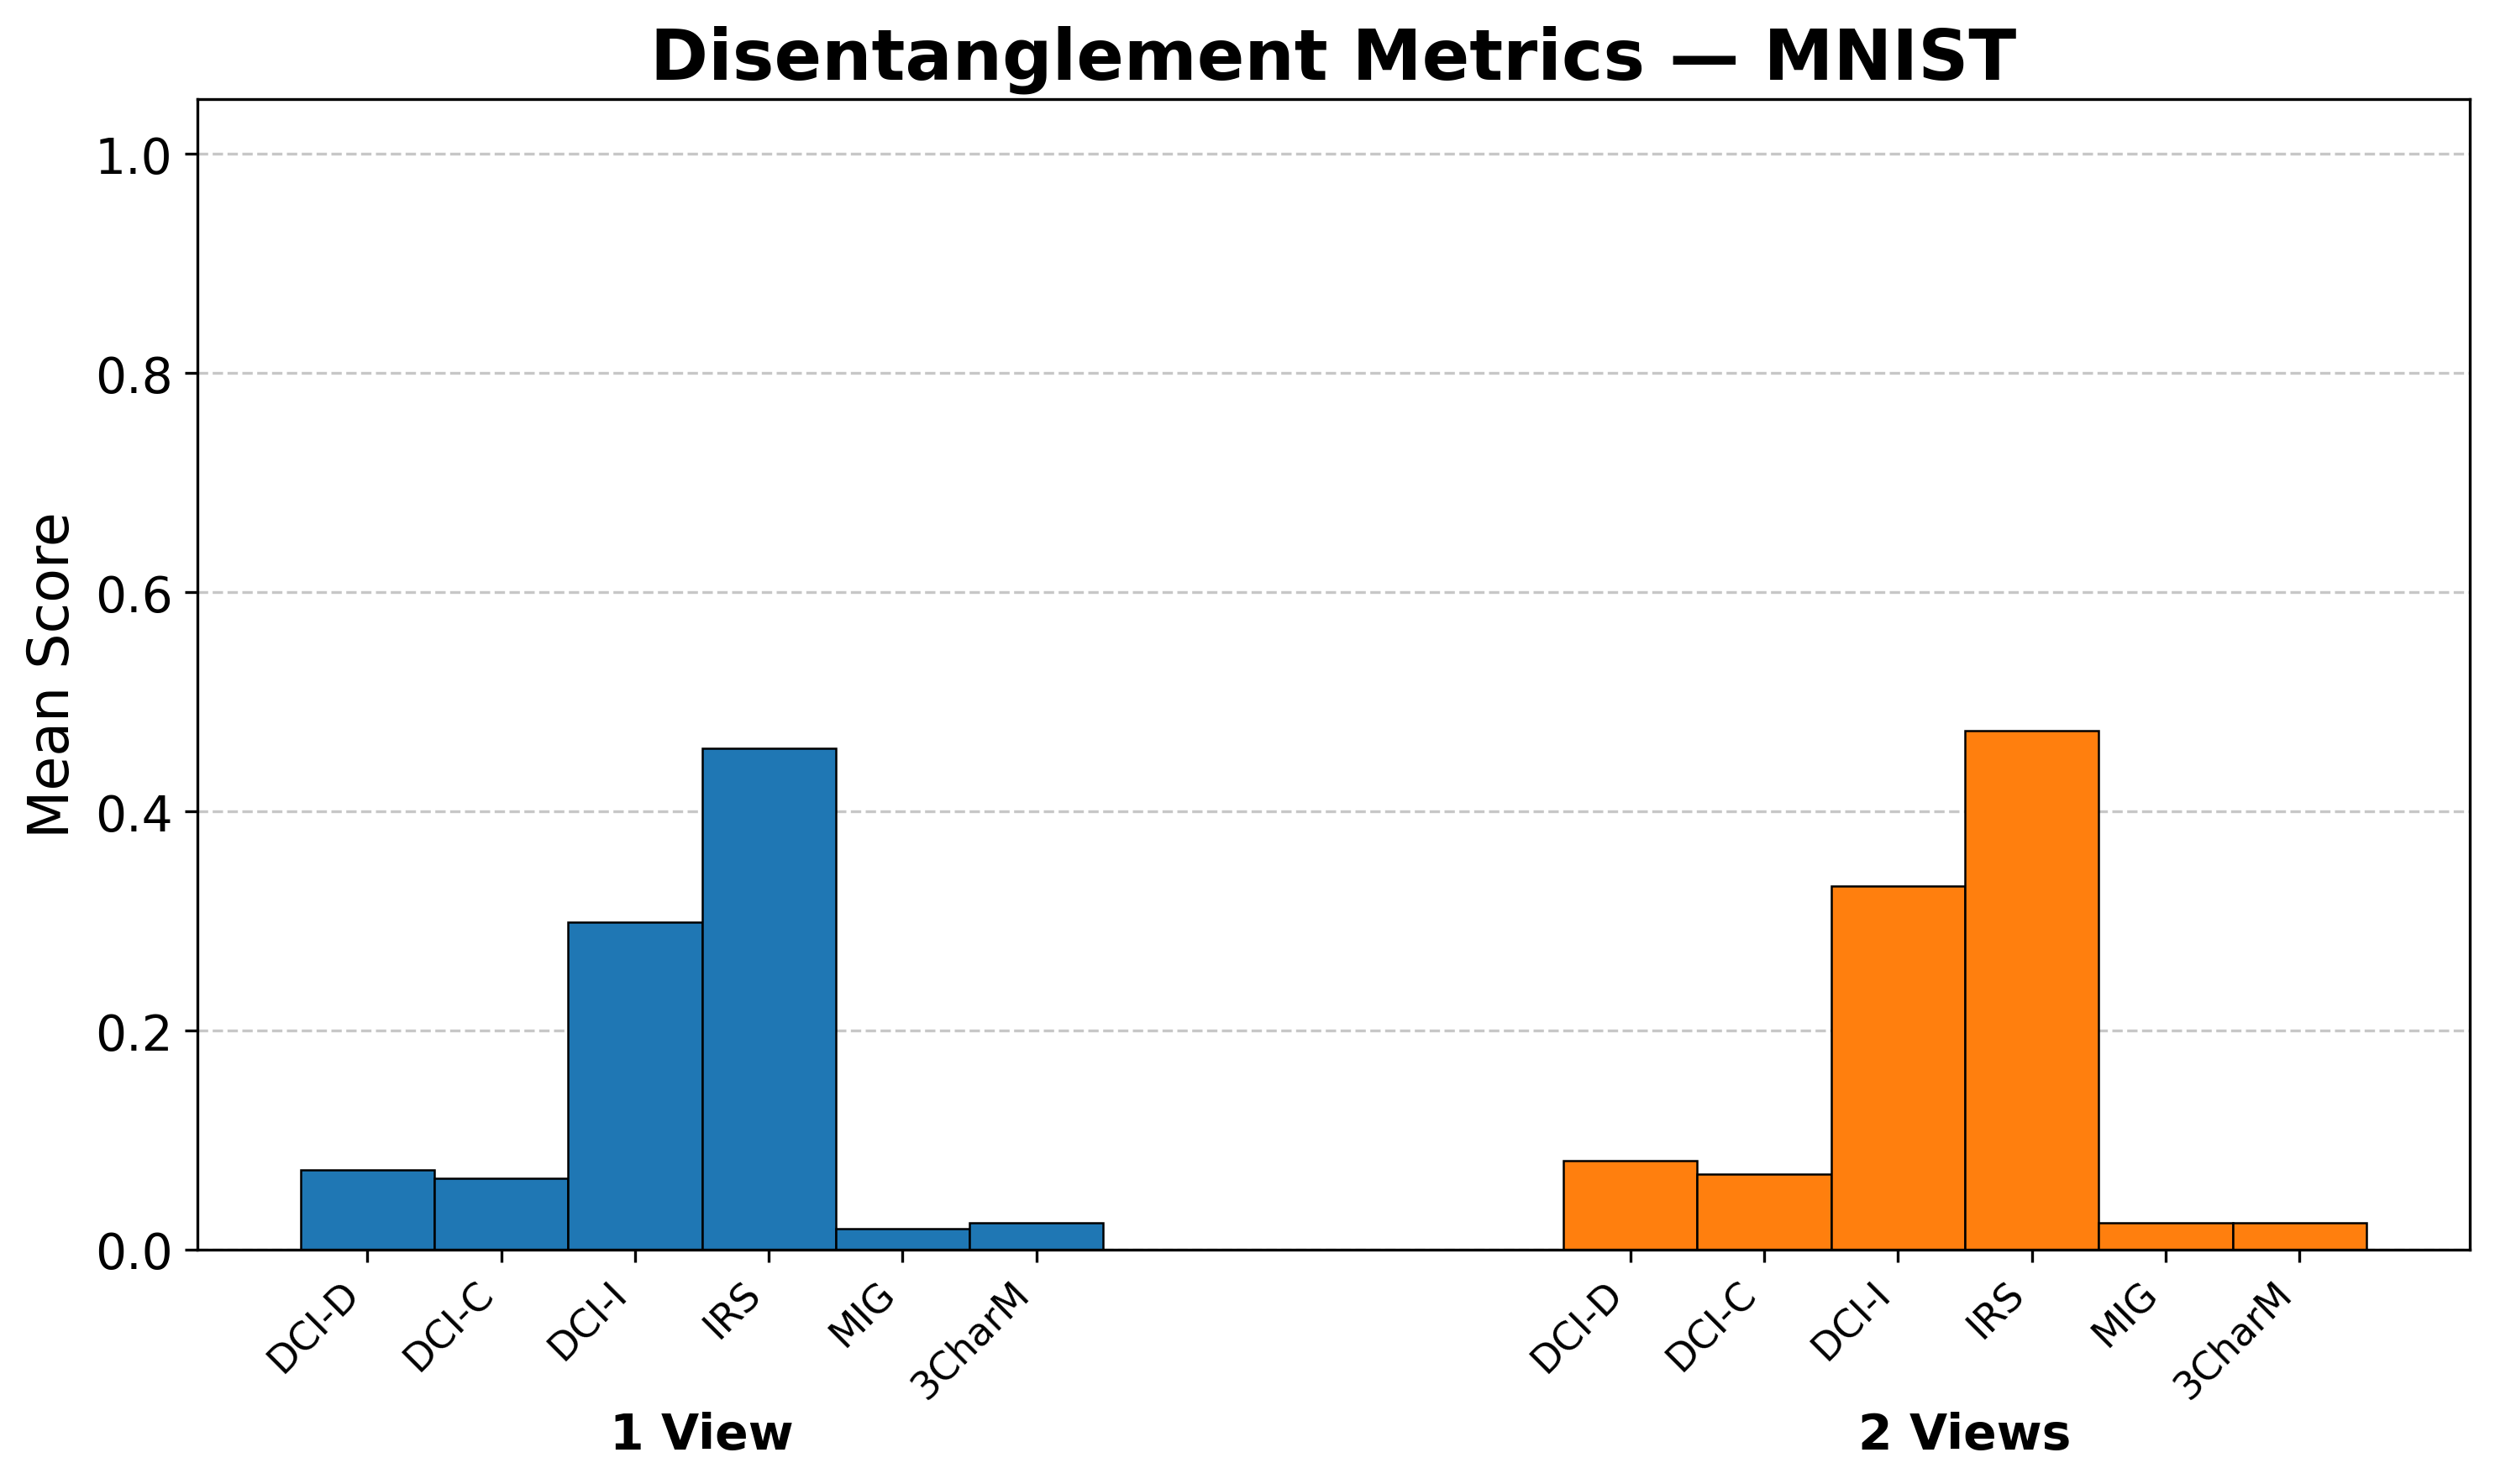

In [20]:
# Model groups
categories = ['1 View', '2 Views']

# Colors depend on the view/model type
model_color_map = {
    '1 View': 'tab:blue',
    '2 Views': 'tab:orange',
}

metric_values = {
    'DCI-D':  [np.mean(np.asarray(v)) for v in [DCI_D_1Vs, DCI_D_2Vs]],
    'DCI-C':  [np.mean(np.asarray(v)) for v in [DCI_C_1Vs, DCI_C_2Vs]],
    'DCI-I':  [np.mean(np.asarray(v)) for v in [DCI_I_1Vs, DCI_I_2Vs]],
    'IRS':    [np.mean(np.asarray(v)) for v in [IRS_1Vs, IRS_2Vs]],
    'MIG':    [np.mean(np.asarray(v)) for v in [MIG_1Vs, MIG_2Vs]],
    '3CharM': [np.mean(np.asarray(v)) for v in [TCM_1Vs, TCM_2Vs]],
}

metrics = list(metric_values.keys())

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bar_width = 0.16
group_gap = 0.55

x_positions = []
x_labels = []

for i, category in enumerate(categories):
    group_start = i * (len(metrics) * bar_width + group_gap)

    for j, metric in enumerate(metrics):
        xpos = group_start + j * bar_width
        x_positions.append(xpos)
        x_labels.append(metric)

        ax.bar(
            xpos,
            metric_values[metric][i],
            width=bar_width,
            color=model_color_map[category],
            edgecolor='black',
            linewidth=0.6
        )

# Metric names as x-ticks instead of legend
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)

# Add model labels centered underneath each metric group
group_centers = [
    i * (len(metrics) * bar_width + group_gap) + (len(metrics) - 1) * bar_width / 2
    for i in range(len(categories))
]

for center, category in zip(group_centers, categories):
    ax.text(
        center,
        -0.14,
        category,
        ha='center',
        va='top',
        fontsize=14,
        fontweight='bold',
        transform=ax.get_xaxis_transform()
    )

ax.set_title('Disentanglement Metrics — MNIST', fontsize=20, fontweight='bold')
ax.set_ylabel('Mean Score', fontsize=16)

ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(0, 1.05)
ax.set_axisbelow(True)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('./img/disentanglement_metrics_comparison.png', dpi=300)
plt.show()

In [21]:
score_lists = {
    'DCI-D': {
        '1 View': DCI_D_1Vs,
        '2 Views': DCI_D_2Vs,
    },
    'DCI-C': {
        '1 View': DCI_C_1Vs,
        '2 Views': DCI_C_2Vs,
    },
    'DCI-I': {
        '1 View': DCI_I_1Vs,
        '2 Views': DCI_I_2Vs,
    },
    'IRS': {
        '1 View': IRS_1Vs,
        '2 Views': IRS_2Vs,
    },
    'MIG': {
        '1 View': MIG_1Vs,
        '2 Views': MIG_2Vs,
    },
    '3CharM': {
        '1 View': TCM_1Vs,
        '2 Views': TCM_2Vs,
    },
}

In [22]:
# Print mean and std for each metric and view type
for metric, views in score_lists.items():
    print(f"{metric}:")
    for view_type, scores in views.items():
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        print(f"  {view_type}: Mean = {mean_score:.6f}, Std = {std_score:.4f}")

DCI-D:
  1 View: Mean = 0.072759, Std = 0.0086
  2 Views: Mean = 0.081493, Std = 0.0101
DCI-C:
  1 View: Mean = 0.065256, Std = 0.0057
  2 Views: Mean = 0.069475, Std = 0.0083
DCI-I:
  1 View: Mean = 0.299167, Std = 0.0412
  2 Views: Mean = 0.331667, Std = 0.0318
IRS:
  1 View: Mean = 0.457835, Std = 0.0204
  2 Views: Mean = 0.474006, Std = 0.0160
MIG:
  1 View: Mean = 0.019412, Std = 0.0077
  2 Views: Mean = 0.024581, Std = 0.0135
3CharM:
  1 View: Mean = 0.024479, Std = 0.0045
  2 Views: Mean = 0.024965, Std = 0.0055


In [23]:
from scipy.stats import ttest_rel

alpha = 0.05
rows = []

for metric_name, view_dict in score_lists.items():
    group_names = list(view_dict.keys())

    if len(group_names) == 2:
        values_1 = np.asarray(view_dict[group_names[0]], dtype=float)
        values_2 = np.asarray(view_dict[group_names[1]], dtype=float)

        # Keep only paired observations where both values are valid
        valid_mask = ~np.isnan(values_1) & ~np.isnan(values_2)

        values_1 = values_1[valid_mask]
        values_2 = values_2[valid_mask]

        if len(values_1) > 1 and len(values_2) > 1:
            t_stat, p_value = ttest_rel(values_1, values_2)

            rows.append({
                'Metric': metric_name,
                'Groups': f'{group_names[0]} vs {group_names[1]}',
                't-statistic': t_stat,
                'p-value': p_value,
                'Significant at α=0.05': 'Yes' if p_value < alpha else 'No'
            })
        else:
            rows.append({
                'Metric': metric_name,
                'Groups': f'{group_names[0]} vs {group_names[1]}',
                't-statistic': np.nan,
                'p-value': np.nan,
                'Significant at α=0.05': 'Too few valid pairs'
            })
    else:
        rows.append({
            'Metric': metric_name,
            'Groups': ', '.join(group_names),
            't-statistic': np.nan,
            'p-value': np.nan,
            'Significant at α=0.05': 'Needs exactly 2 groups'
        })

paired_ttest_results = pd.DataFrame(rows)

paired_ttest_results

,Metric,Groups,t-statistic,p-value,Significant at α=0.05
0,DCI-D,1 View vs 2 Views,-4.587394,0.001314,Yes
1,DCI-C,1 View vs 2 Views,-2.262188,0.049998,Yes
2,DCI-I,1 View vs 2 Views,-3.683327,0.005049,Yes
3,IRS,1 View vs 2 Views,-2.235233,0.052248,No
4,MIG,1 View vs 2 Views,-1.361070,0.206593,No
5,3CharM,1 View vs 2 Views,-0.214577,0.834880,No


In [ ]:
# # Export 2V disentanglement scores to CSV 
# # With the following columns: Model, DCI-D, DCI-C, DCI-I, IRS, MIG, 3CharM
# export_rows = []

# for i in range(len(score_lists['DCI-D']['2 Views'])):
#     export_rows.append({
#         'Architecture': 'MNIST',
#         'Views': '2 Views',
#         'DCI-D': score_lists['DCI-D']['2 Views'][i],
#         'DCI-C': score_lists['DCI-C']['2 Views'][i],
#         'DCI-I': score_lists['DCI-I']['2 Views'][i],
#         'IRS': score_lists['IRS']['2 Views'][i],
#         'MIG': score_lists['MIG']['2 Views'][i],
#         '3CharM': score_lists['3CharM']['2 Views'][i]
#     })

# export_df = pd.DataFrame(export_rows)
# # Append to CSV (or create if it doesn't exist)
# export_df.to_csv('../CrossModel/disentanglement_scores.csv', index=False, mode='a', header=not os.path.exists('../CrossModel/disentanglement_scores.csv'))